Raw Flow Data Assessment

This workbook defines resampling procedures and visualizes gaps in the observed flow data. This analysis assisted in whittling down candidate sites for the observed network. 

Functions defined:<br>
max_consecutive_nans(array)<br>
day_to_month(dataframe)<br>
day_to_season(dataframe)<br>

The results of the assessment are found in ../figures/assessments/

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import os
import datetime
import matplotlib.dates as mdates

pd.plotting.register_matplotlib_converters()

In [4]:
# Store site metadata (site number, site name, catchment number, NZTME, NZTMN)

metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)

# define alpha and numeric season order
seasons_a = ['fall','winter','spring','summer']
seasons_n = [3,6,9,12]

In [5]:
'''
Helper function for null value handling. 
Returns the maximum length of consecutive nan values in an array.
'''

def max_consecutive_nans(a):
    mask = np.concatenate(([False],np.isnan(a),[False]))
    if ~mask.any():
        return 0
    else:
        idx = np.nonzero(mask[1:] != mask[:-1])[0]
        return (idx[1::2] - idx[::2]).max()

In [6]:
'''
Resample daily flow to monthly based on the following missing value criteria:
- if season has more than 1/3 missing days = nan season mean
- if season has more than 7 consecutive missing days = nan season mean
'''

def day_to_season(df):
    
    start_year = int(df.index.year[0])
    end_year = int(df.index.year[-1])
    end_month = int(df.index.month[-1])
    start_month = int(df.index.month[0] )
    
    #print(start_year)
    #print(end_year)
    #print(start_month)
    #print(end_month)
    
    df_dict = {'date':[], 'flow':[]}

    for year in range(start_year, end_year + 1):
        for month in range(1,13):
            if (((year == start_year) and (month < start_month)) or ((year == end_year) and (month > end_month))):
                continue
            
            if month in [12,3,6,9]:
                dt = datetime.date(year, month, 1)
                
                if month == 12:
                    if year + 1 > end_year:
                        break
                    year_data = df[str(year)]
                    dec = year_data[year_data.index.month == 12]#.flow
                    next_year_data = df[str(year + 1)]
                    jan_feb = next_year_data[next_year_data.index.month.isin([1,2])]#.flow
                    season_data = pd.concat([dec, jan_feb])
                else:    
                    year_data = df[str(year)]
                    season_data = year_data[year_data.index.month.isin([month, month+1, month+2])]#.flow

                percentage_null = season_data.isnull().sum() / len(season_data)
                
                df_dict['date'].append(dt)
                if (percentage_null > .33) or (max_consecutive_nans(season_data.values) > 7):
                    df_dict['flow'].append(math.nan)

                else:
                    df_dict['flow'].append(np.nanmean(season_data.values))
                    
    new_df = pd.DataFrame(data=df_dict)
    new_df.date = pd.to_datetime(new_df.date)
    new_df.set_index('date', inplace=True)
    return new_df

In [7]:
'''
resampling daily data from daily to monthly or seasonal, writing to new csv files
'''

filepath = '/nesi/project/niwa00015/queenle/data/flows/daily/50yrs/'

df_list = []

for filename in os.listdir(filepath):
    
    if filename == 'full_records.csv':
        continue

    header = open(filepath + filename).readline().strip().split(' ')
    site_number = header[1]
    site_name = " ".join(header[2:])
                
    #if site_number != '95101':
    #    continue
    
    site_df = pd.read_csv(filepath + filename, header=1)
    site_df.Date = pd.to_datetime(site_df.Date)
    site_df.set_index('Date', inplace=True)
    site_df.columns = ['time','flow']
    site_df = site_df.replace('gap ', math.nan)
    site_df["flow"] = pd.to_numeric(site_df["flow"])
        
    #print(site_number + ': ' + str(site_df['flow'].mean()))
    
    replace_dates = {}
    for date in site_df.index:
        if date.year > 2020:
            new_date = date.replace(year=date.year - 100)
            replace_dates[date] = new_date
            
    site_df.rename(replace_dates,inplace=True)
        
    data = day_to_season(site_df)
    
    data.columns = [site_number]
    
    df_list.append(data)
    
    #data.to_csv("/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/individual_sites/" + site_number + ".csv")

combined_df = pd.concat(df_list,axis=1)

    

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [10]:
# concatenating seasonal records to a single csv file

directory = '/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/individual_sites/'

#print(os.listdir(directory))

df_list = []
for file in os.listdir(directory):
    
    df = pd.read_csv(directory + file)
    #print(df)
    df.date = pd.to_datetime(df.date)
    df.set_index('date', inplace=True)
    
    site_number = file.split('.')[0]
    
    #if file == '64610.csv':
    #    df['flow'] = df['flow']/1000
        
    df.columns = [site_number]
    
    df_list.append(df)
    
combined_df = pd.concat(df_list,axis=1)
    
#combined_df.to_csv("/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/new_full_records.csv")    
    

In [166]:
new = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/new_full_records.csv')
new.date = pd.to_datetime(new.date)
new.set_index('date', inplace=True)


In [167]:
old = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/full_records.csv')
old.date = pd.to_datetime(old.date)
old.set_index('date', inplace=True)



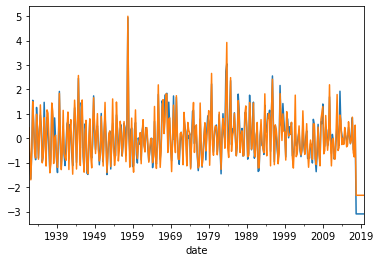

In [127]:
((old['71132']-old['71132'].mean())/old['71132'].std()).plot()
((new['71132']-new['71132'].mean())/new['71132'].std()).plot()


In [168]:
old = old.fillna(0)
new = new.fillna(0)
old = old.replace('NaN', 0)
new = new.replace('Nan', 0)

In [169]:
compare = (old == new)

In [83]:
old['64610'].values

array([   0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.     

In [82]:
old['64610'].where(~compare['64610'])

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
348   NaN
349   NaN
350   NaN
351   NaN
352   NaN
Name: 64610, Length: 353, dtype: float64

In [68]:
new['64610'].where(~compare['64610'])

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
348   NaN
349   NaN
350   NaN
351   NaN
352   NaN
Name: 64610, Length: 353, dtype: float64

In [171]:
bol = compare.loc[: , (compare == False).any()]
bol

,71132,71120,75292,79713,21412,75288,71123,79704,64610
date,,,,,,,,,
1931-12-01,False,False,False,True,False,False,False,False,True
1932-03-01,False,False,False,False,False,False,False,False,True
1932-06-01,False,False,False,False,False,False,False,False,True
1932-09-01,False,False,False,False,False,False,False,False,True
1932-12-01,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...
2018-12-01,True,True,True,True,True,True,True,True,True
2019-03-01,True,True,True,True,True,True,True,True,True
2019-06-01,True,True,True,True,True,True,True,True,True


In [97]:
ins = []
for i in range(len(bol['64610'].values.tolist())):
    if bol['64610'].values[i] == True:
        ins.append(i)

In [124]:
new_std = (new - new.mean())/new.std()
old_std = (old - old.mean())/old.std()

for i in old_std['71132'].index:
    if old_std['71132'].loc[i] != new_std['71132'].loc[i]:
        print('old: ' + str(old_std['71132'].loc[i]))
        print('new: ' + str(new_std['71132'].loc[i]))

old: -0.10672925677878917
new: 0.42573658942854986
old: -0.9473104264892919
new: -0.6144253125580359
old: -1.6581903637173387
new: -1.7020765177440988
old: -0.45363765043110094
new: -0.43147571654355116
old: 1.554401876813579
new: 1.4992149641351247
old: 0.4622492717234027
new: 0.5847024889192791
old: -0.4373751772231068
new: -0.6336847365915089
old: -0.8798550985348474
new: -0.8088920548461923
old: 1.2609544282474763
new: 0.9803652258350489
old: 0.36895519407477834
new: 0.413554472326591
old: -0.8089820245643895
new: -0.8588727356046215
old: 0.2782169020457969
new: 0.12337434338393297
old: 0.9514026532254746
new: 1.3655259000135607
old: 0.475764370106954
new: 0.23261370790140223
old: -0.9596778134801335
new: -1.0079931483474303
old: -0.7111370165206241
new: -0.7365470003765195
old: 1.470566359943928
new: 0.838886698772871
old: 0.018435939758606048
new: 0.11883060682844017
old: -0.9225682025238124
new: -1.1387403910227611
old: 0.8426488510095924
new: 1.1605516598900156
old: 0.324741526

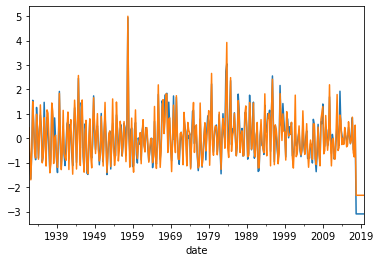

In [125]:
old_std['71132'].plot()
new_std['71132'].plot()

In [159]:
what_is_this = pd.read_csv("/nesi/project/niwa00015/queenle/data/flows/daily/50yrs/full_records.csv")
what_is_this.Date = pd.to_datetime(what_is_this.Date)
what_is_this.set_index('Date', inplace=True)
what_is_this

,71132,46618,64602,71135,77505,16501,1043427,71120,71129,62103,...,1043461,71123,57009,95101,65104,29224,79704,75232,64610,93203
Date,,,,,,,,,,,,,,,,,,,,,
1931-12-31,69812.0,NaN,NaN,NaN,NaN,NaN,NaN,75988.0,NaN,NaN,...,NaN,143956.0,NaN,NaN,NaN,NaN,235486.0,NaN,NaN,NaN
1932-01-01,31567.0,NaN,NaN,NaN,NaN,NaN,NaN,80976.0,NaN,NaN,...,NaN,154576.0,NaN,NaN,NaN,NaN,230096.0,NaN,NaN,NaN
1932-01-02,112951.0,NaN,NaN,NaN,NaN,NaN,NaN,83969.0,NaN,NaN,...,NaN,161503.0,NaN,NaN,NaN,NaN,224642.0,NaN,NaN,NaN
1932-01-03,26590.0,NaN,NaN,NaN,NaN,NaN,NaN,83969.0,NaN,NaN,...,NaN,162717.0,NaN,NaN,NaN,NaN,272744.0,NaN,NaN,NaN
1932-01-04,63597.0,NaN,NaN,NaN,NaN,NaN,NaN,83969.0,NaN,NaN,...,NaN,163931.0,NaN,NaN,NaN,NaN,297516.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,55318.0,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,44903.0,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,40566.0,NaN,NaN,NaN,NaN,NaN,NaN


In [158]:
old_daily.columns = ['flow']
old_daily

Date
1931-12-31     69.812
1932-01-01     31.567
1932-01-02    112.951
1932-01-03     26.590
1932-01-04     63.597
               ...   
2020-08-01        NaN
2020-09-01        NaN
2020-10-01        NaN
2020-11-01        NaN
2020-12-01        NaN
Name: 71132, Length: 32210, dtype: float64

In [163]:
old_daily = what_is_this['71132']/1000
old_daily.columns = ['flow']
#old_daily = old_daily.replace('gap ', math.nan)
#old_daily["flow"] = pd.to_numeric(what_is_this["flow"])

old_daily_to_season = day_to_season(old_daily)

In [164]:
old_daily_to_season

,flow
date,
1931-12-01,96.288639
1932-03-01,60.019957
1932-06-01,22.095402
1932-09-01,66.399099
1932-12-01,133.719011
...,...
2019-09-01,NaN
2019-12-01,NaN
2020-03-01,NaN


In [165]:
old

,71132,46618,64602,71135,77505,16501,1043427,71120,71129,62103,...,1043461,71123,57009,95101,65104,29224,79704,75232,64610,93203
date,,,,,,,,,,,,,,,,,,,,,
1931-12-01,78.576574,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,76.951508,0.000000,0.000000,...,0.000000,159.659213,0.000000,0.000000,0.000000,0.000000,287.479377,0.000000,0.000000,0.000000
1932-03-01,56.501152,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,49.722337,0.000000,0.000000,...,0.000000,90.008630,0.000000,0.000000,0.000000,0.000000,207.932402,0.000000,0.000000,0.000000
1932-06-01,37.831957,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.460109,0.000000,0.000000,...,0.000000,52.937391,0.000000,0.000000,0.000000,0.000000,192.698522,0.000000,0.000000,0.000000
1932-09-01,69.466033,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72.203505,0.000000,0.000000,...,0.000000,108.435769,0.000000,0.000000,0.000000,0.000000,298.220132,0.000000,0.000000,0.000000
1932-12-01,122.201356,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,110.117544,0.000000,0.000000,...,0.000000,215.691567,0.000000,0.000000,0.000000,0.000000,314.353711,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-01,0.000000,4295.600000,57341.100000,8354.000000,14495.722222,38940.688889,8291.711111,0.000000,3330.822222,13441.322222,...,6035.977778,0.000000,21565.577778,70480.833333,34513.600000,16060.600000,0.000000,13712.222222,302.570233,169420.733333
2019-03-01,0.000000,1952.173913,62849.456522,9826.586957,20431.250000,46286.695652,6251.478261,0.000000,2948.923913,13547.804348,...,7557.217391,0.000000,22761.869565,122758.554348,37078.913043,14580.326087,0.000000,12536.358696,229.510348,379698.869565
2019-06-01,0.000000,10345.097826,88507.608696,6307.989130,20872.467391,100586.456522,13190.293478,0.000000,2572.630435,27099.380435,...,18877.184783,0.000000,59794.184783,132343.217391,51653.163043,31492.413043,0.000000,43290.326087,758.822033,515798.000000


In [30]:
# concatenating records to a single csv file

directory = '/nesi/project/niwa00015/queenle/data/flows/daily/50yrs/'

#print(os.listdir(directory))

df_list = []
for file in os.listdir(directory):
    
    df = pd.read_csv(directory + file, header=1)
    df.Date = pd.to_datetime(df.Date)
    df.set_index('Date', inplace=True)
    df.columns = ['time','flow']
    df = df.replace('gap ', math.nan)
    df["flow"] = pd.to_numeric(df["flow"])
    df.drop('time',axis=1,inplace=True)
        
    site_number = file.split('.')[0]
        
    #print(site_number)
    
    df.columns = [site_number]
    
    replace_dates = {}
    for date in df.index:
        if date.year > 2020:
            new_date = date.replace(year=date.year - 100)
            replace_dates[date] = new_date
            
    df.rename(replace_dates,inplace=True)
    
    #print(df)
    
    df_list.append(df)
    
combined_df = pd.concat(df_list,axis=1)
    
#print(combined_df)
    
    

In [32]:
combined_df.to_csv("/nesi/project/niwa00015/queenle/data/flows/daily/50yrs/50plus_all_sites.csv")

In [ ]:
'''
Reading seasonal data, saving metadata and missing value information for plotting.
'''

sites = []

color_dict = {12:'y',3:'r',6:'b',9:'lime'}

filepath = '../data/flows/seasonal/40_50yrs/individual_sites/'

for filename in os.listdir(filepath):

    site_number = int(filename[:-4])
    #print(site_number)
    site_name = metadata_df.loc[site_number]['Name']
    cat3 = metadata_df.loc[site_number]['cat3']
        
    data = pd.read_csv(filepath + filename, header=0)
    data.date = pd.to_datetime(data.date)
    data.set_index('date', inplace=True)
    
    data = data['1979-12-01':'2019-09-01']
    #data = data['1969-12-01':'2019-09-01']
        
    colors = []
    dates = []
    for d in data.index:
        dates.append(d)
        if not np.isnan(data[data.index == d].flow.values[0]):
            colors.append('dimgrey')
        else:
            colors.append(color_dict[d.month])
            
    # special handling of lake inflows which end in 2017. Adding missing seasons 2017-2019.
    if data.index.year[-1] < 2019:
        dates.append(pd.to_datetime("{}/{}/{}".format(2017,12,1)))
        colors.append(color_dict[12])
        for y in range(2018,2020):
            for m in [3, 6, 9, 12]:
                dates.append(pd.to_datetime("{}/{}/{}".format(y,m,1)))
                colors.append(color_dict[m])
        del dates[-1]
        del colors[-1]

    sites.append([site_name, site_number, dates, colors, cat3])


# Order sites by catchment number and separate into north and south islands.
sites.sort(key=lambda x: int(x[4]))
sites.reverse()
NI = [lst for lst in sites if int(lst[4]) < 500]
SI = [lst for lst in sites if int(lst[4]) > 500]

In [ ]:
'''
Plotting stacked timelines. Missing seasons colored as following:
yellow: summer
red: fall
blue: winter
green: spring
'''

site_lists = [NI, SI]

#file_names = ['../figures/data_assessments/40_50_sites/NI_window.png',
#              '../figures/data_assessments/40_50_sites/SI_window.png']

file_names = ['../figures/data_assessments/50yr_sites/NI_window.png',
              '../figures/data_assessments/50yr_sites/SI_window.png']

titles = ['North Island', 'South Island']
for i in range(len(site_lists)):
    y = []
    ys = []
    names = []
    dates = []
    colors = []
    for j in range(len(site_lists[i])):
        y.append(j)
        ys.append([j]*len(site_lists[i][j][2]))
        names.append(site_lists[i][j][0] + " (" + str(site_lists[i][j][1]) + ")")
        dates.append(site_lists[i][j][2])            
        colors.append(site_lists[i][j][3])
    
    flat_dates = [item for sublist in dates for item in sublist]
    flat_ys = [item for sublist in ys for item in sublist]
    flat_colors = [item for sublist in colors for item in sublist]
            
    fig, axs = plt.subplots(1,1, figsize=(16,14))

    plt.scatter(flat_dates, flat_ys, s =100, marker = '|', c=flat_colors)
    
    plt.title(titles[i])
    
    for k in range(len(flat_dates)):
        if flat_dates[k].year == 1979 and flat_dates[k].month == 12:
            plt.axvline(flat_dates[k], color='black', zorder=0)
        if flat_dates[k].year == 2019 and flat_dates[k].month == 9:
            plt.axvline(flat_dates[k], color='black', zorder=0)
            
    axs.xaxis.set_major_locator(mdates.YearLocator(5))
    axs.xaxis.grid(True)
    axs.set_facecolor('grey')
    plt.yticks(y, names)
    
    plt.tight_layout()
    #plt.savefig(file_names[i])#, dpi=1200)
    #plt.close()


In [ ]:
fig,ax = plt.subplots(figsize=(12,14))

tick_labels = []
for n,site in enumerate(combined_df):
    vals = combined_df[site].values
    years = combined_df[site].index.year.values
    
    colors = ['red' if math.isnan(val) else 'blue' for val in vals]
    tick_labels.append(site)
    
    plt.scatter(years,[n for i in range(len(colors))],c=colors,marker='s')
    
plt.yticks([i for i in range(len(combined_df.columns))],tick_labels)

plt.show()
